# JPA Planck Spectroscopy Analysis

Here we fit the planck data to the bosonic noise temperature curve to evaluate the added photons along the output line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

import importlib
import LKIPA_resonance_PSD as psd
importlib.reload(psd)

<module 'LKIPA_resonance_PSD' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/LKIPA_resonance_PSD.py'>

# 0. Functions

---


## 0.1 Load hdf5 data

In [2]:
# Load Exp Data
def load_ExpData(file_):
    with h5py.File(file_, "r") as dataset:
        # Data is stored under "Planck Spectroscopy/{myrun}/..."
        sample_grp = dataset["Planck Spectroscopy"]
        myrun = list(sample_grp.keys())[0]
        run_grp = sample_grp[myrun]

        return {
            "run":          myrun,
            "freq_comb":    np.asarray(run_grp["freq comb"]),
            "USB":          np.asarray(run_grp["USB"]),
            "LSB":          np.asarray(run_grp["LSB"]),
            "temperature":  np.asarray(run_grp["temperature"]),
        }

In [4]:
file = '/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/JPA/2026-03-JPA-planck_19.96mk.hdf5'

data = load_ExpData(file_=file)

covariance_usb = np.array(data['USB'])
covariance_lsb = np.array(data['LSB'])
freq_comb      = data['freq_comb']

modes = int(len(freq_comb))
print('Modes = ' + str(modes))

Modes = 96


In [25]:
temp = np.real(data['temperature'])
print('Temperature = ' + str(temp) + ' K')

Temperature = 19.96 K


## 0.2 Covariance matrix from USB, LSB data

In [7]:
def covariance_matrix(lsb_arr, usb_arr, chunk_size=50_000):
    """
    Compute the quadrature covariance matrix over [LSB | USB] modes without
    materialising the full concatenated array.

    Uses the single-pass identity:
        cov = (ΣxxT - N * mean ⊗ mean) / (N - 1)

    Memory per chunk: chunk_size × 2*(M_lsb + M_usb) × 8 bytes
    e.g. chunk_size=50_000, 192 modes → ~153 MB
    """
    N      = lsb_arr.shape[0]
    M_lsb  = lsb_arr.shape[1]
    M_usb  = usb_arr.shape[1]
    M2     = 2 * (M_lsb + M_usb)   # total quadratures

    sum_x  = np.zeros(M2,       dtype=np.float64)
    sum_xx = np.zeros((M2, M2), dtype=np.float64)

    for i in tqdm(range(0, N, chunk_size), desc="Building covariance"):
        lsb_c  = lsb_arr[i:i + chunk_size]
        usb_c  = usb_arr[i:i + chunk_size]
        n      = len(lsb_c)

        xp = np.empty((n, M2), dtype=np.float64)
        # LSB quadratures: cols 0 .. 2*M_lsb-1, interleaved Re/Im
        xp[:, 0:2*M_lsb:2]   = np.real(lsb_c)
        xp[:, 1:2*M_lsb:2]   = np.imag(lsb_c)
        # USB quadratures: cols 2*M_lsb .. M2-1, interleaved Re/Im
        xp[:, 2*M_lsb::2]    = np.real(usb_c)
        xp[:, 2*M_lsb+1::2]  = np.imag(usb_c)

        sum_x  += xp.sum(axis=0)
        sum_xx += xp.T @ xp

    mean = sum_x / N
    return (sum_xx - N * np.outer(mean, mean)) / (N - 1)


cov_mat = covariance_matrix(covariance_lsb, covariance_usb)


def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])

    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R

    return R_big @ cov_mat @ R_big.T

# theta   = 3*np.pi/16
# cov_mat = cov_rotation(cov_mat, theta)

Building covariance: 100%|██████████| 50/50 [00:11<00:00,  4.24it/s]


## 0.3 Extract diagonal from single planck file

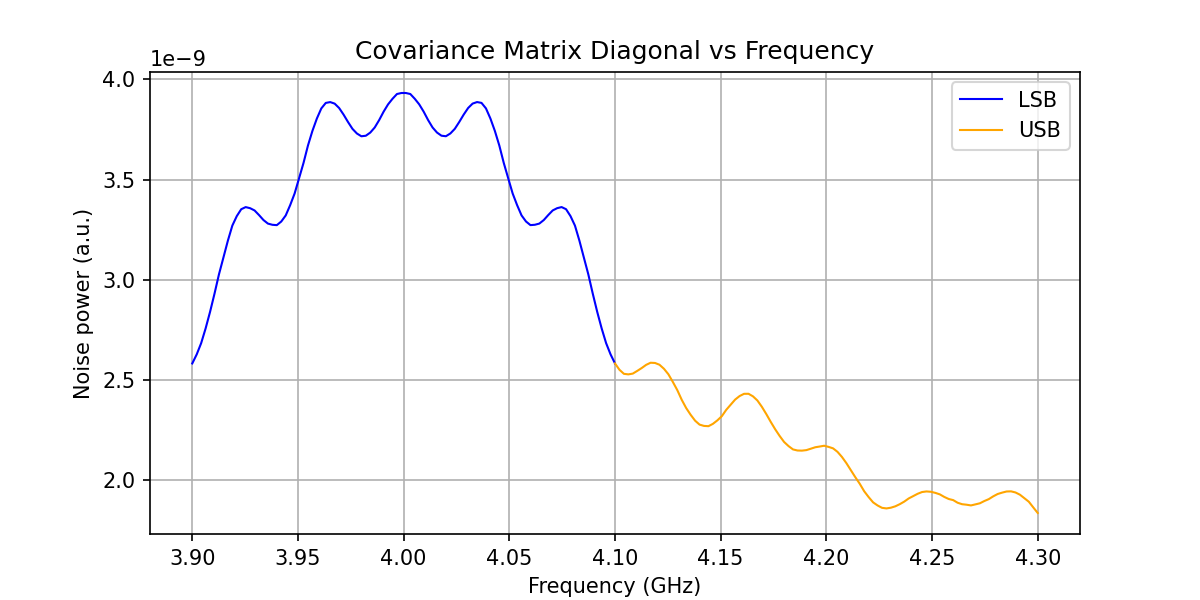

In [23]:
# ── Diagonal extraction ───────────────────────────────────────────────────────
def get_cov_diagonal(cov_mat, freq_comb):
    """Return (freqs_GHz, power) for the full band, sorted ascending in frequency."""
    diag  = np.diag(cov_mat)
    M     = len(freq_comb)

    lsb_power = diag[0:2*M:2] + diag[1:2*M:2]
    usb_power = diag[2*M::2]  + diag[2*M+1::2]

    usb_freqs = (freq_comb) / 1e9
    lsb_freqs = usb_freqs - (freq_comb[-1] - freq_comb[0]) / 1e9

    freqs = np.concatenate([lsb_freqs, usb_freqs])
    power = np.concatenate([lsb_power, usb_power])
    order = np.argsort(freqs)
    return freqs[order], power[order]


# ── Plot + optional Lorentzian fit ────────────────────────────────────────────
def plot_cov_diagonal(cov_mat, freq_comb):
    """
    Plot the covariance-matrix diagonal as noise power vs frequency.
    """
    freqs, power = get_cov_diagonal(cov_mat, freq_comb)

    lsb_mask = freqs <= freq_comb[0] / 1e9
    usb_mask = freqs >= freq_comb[0] / 1e9

    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    ax.plot(freqs[lsb_mask], power[lsb_mask], color='blue',   lw=1, label='LSB')
    ax.plot(freqs[usb_mask], power[usb_mask], color='orange', lw=1, label='USB')

    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Noise power (a.u.)")
    ax.set_title("Covariance Matrix Diagonal vs Frequency")
    ax.legend()
    ax.grid()

plot_cov_diagonal(cov_mat, freq_comb)

# 1. Data Extraction
---
Loop over all HDF5 files, compute the covariance matrix, fit the diagonal, save figures, and collect fitting parameters.